In [1]:
#import the libraries
import math
import pandas_datareader as web
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

#

In [2]:
import yfinance as yf
#get the stock quote
df = yf.download('AAPL', start='2012-01-01', end='2019-12-17')
#show the data
df

/tmp/ipykernel_24862/3923142106.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2012-01-01', end='2019-12-17')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2012-01-03,12.310349,12.348368,12.243594,12.255568,302220800
2012-01-04,12.376503,12.413624,12.251972,12.273525,260022000
2012-01-05,12.513903,12.529469,12.353448,12.421702,271269600
2012-01-06,12.644723,12.655200,12.549529,12.565993,318292800
2012-01-09,12.624665,12.804877,12.613290,12.737522,394024400
...,...,...,...,...,...
2019-12-10,64.658562,65.041484,64.027576,64.687460,90420400
2019-12-11,65.210052,65.289531,64.663367,64.738024,78756800


In [3]:
#get the number of rows and columns
df.shape

(2002, 5)

Text(0, 0.5, 'Close Price USD ($)')

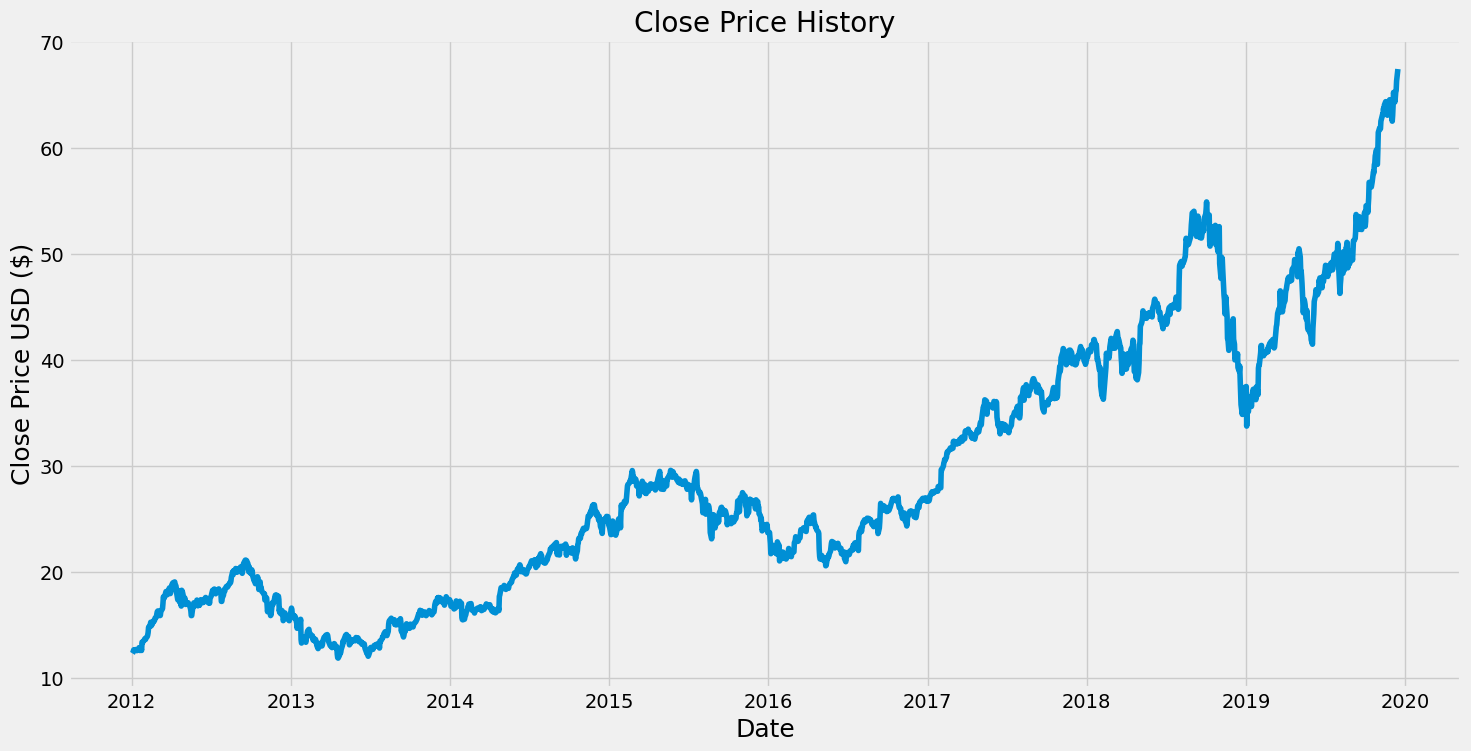

In [4]:
#visualize the closing price
plt.figure(figsize=(16,8))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)

In [5]:
#create a new dataframe with only the close column
data=df[['Close']]
#convert the dataframe to numpy array
dataset=data.values
#get the number of rows to train the model on
training_data_len=math.ceil(len(dataset)*0.8)

training_data_len

1602

In [6]:
#scale the data
scaler= MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(dataset)
scaled_data

array([[0.0080508 ],
       [0.00924199],
       [0.01171605],
       ...,
       [0.96357339],
       [0.97957499],
       [1.        ]])

In [7]:
#create the training dataset
#create the scaled training data set
train_data=scaled_data[0:training_data_len, :]
#split the data into x_train and y_train data sets
x_train=[]
y_train=[]
for i in range(60, len(train_data)):
  x_train.append(train_data[i-60:i, 0])
  y_train.append(train_data[i, 0])
  if i<=60:
    print(x_train)
    print(y_train)
    print()

[array([0.0080508 , 0.00924199, 0.01171605, 0.01407165, 0.01371048,
       0.01452443, 0.01415258, 0.01352727, 0.01267558, 0.01531144,
       0.01768859, 0.01695542, 0.01293966, 0.01677221, 0.012999  ,
       0.02714849, 0.02605426, 0.02748266, 0.0305713 , 0.03244173,
       0.0322854 , 0.03170865, 0.03416661, 0.03647898, 0.03909882,
       0.0433301 , 0.05221861, 0.05235338, 0.05730174, 0.06099932,
       0.05464427, 0.05709131, 0.057043  , 0.0639047 , 0.06292915,
       0.0647348 , 0.0679798 , 0.06978562, 0.07498704, 0.07877657,
       0.07987064, 0.08025348, 0.07377448, 0.07221123, 0.07244302,
       0.07853396, 0.08024805, 0.0839298 , 0.09260798, 0.10418608,
       0.10201947, 0.10202479, 0.11039592, 0.11301554, 0.11115057,
       0.10944723, 0.10767379, 0.11356529, 0.11760807, 0.11930063])]
[np.float64(0.11511762287331262)]



In [8]:
#convert x_train and y_train to numpy
x_train , y_train = np.array(x_train), np.array(y_train)


In [9]:
#reshape the data
x_train=np.reshape(x_train,(x_train.shape[0],x_train.shape[1],1))
x_train.shape



(1542, 60, 1)

In [10]:
from keras.src.models import model
#build the lstm model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
#compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [12]:
#train the model
model.fit(x_train,y_train,batch_size=1, epochs=1)

1542/1542 ━━━━━━━━━━━━━━━━━━━━ 45s 27ms/step - loss: 7.8560e-04


In [13]:
#create the testing dataset
#create a new array containing scaled values from 1543 to 2003
test_data=scaled_data[training_data_len-60:, :]
#create the datasets x_test and y_test
x_test=[]
y_test=dataset[training_data_len, :]
for i in range(60, len(test_data)):
  x_test.append(test_data[i-60:i, 0])

In [14]:
#convert the data to numpy array
x_test=np.array(x_test)

In [15]:
#reshape the data
x_test= np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))


In [16]:
#get the models predicted price values
predictions= model.predict(x_test)
predictions=scaler.inverse_transform(predictions)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


In [17]:
#get the Root Mean Squared Error (RMSE)
rmse=np.sqrt(np.mean(predictions-y_test)**2)
rmse

np.float64(6.364148302078247)

/tmp/ipykernel_24862/1634683378.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions']=predictions


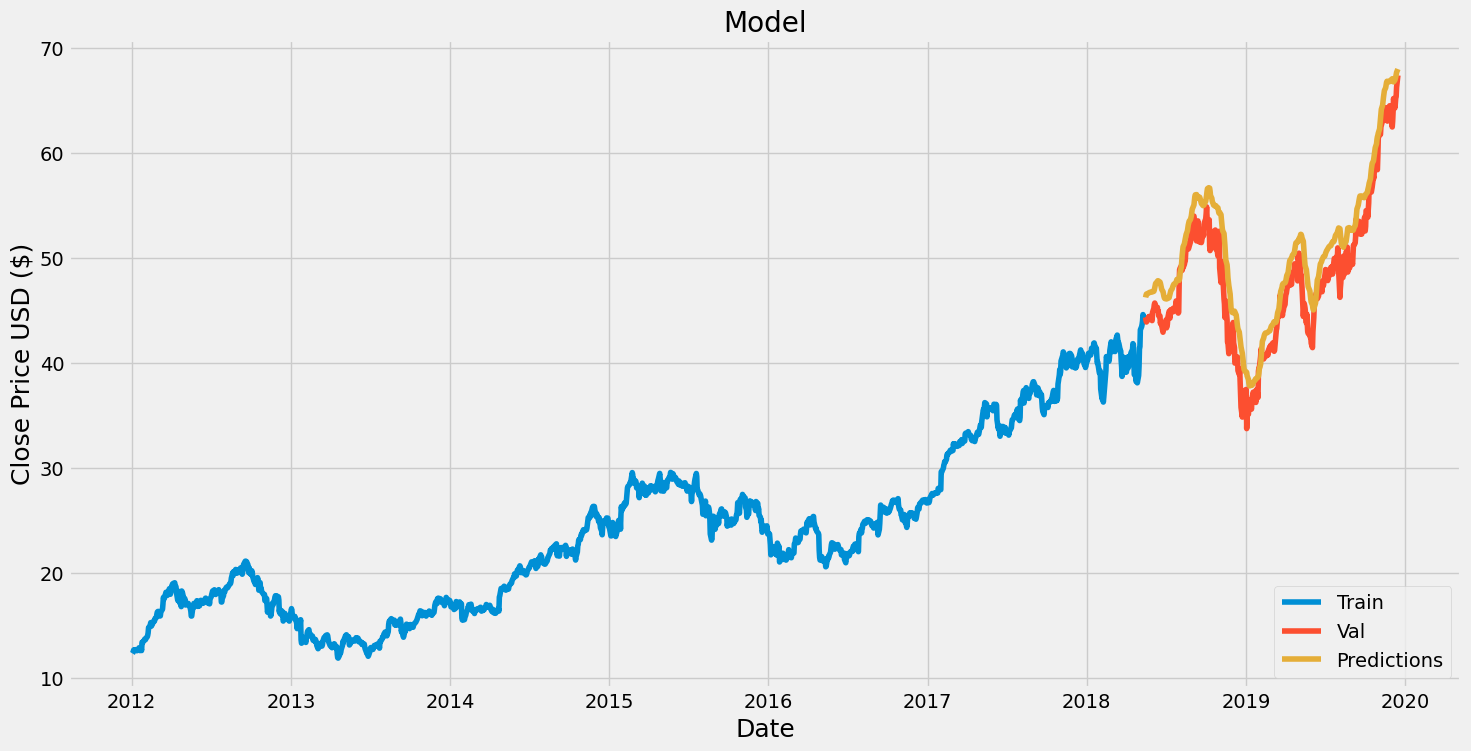

In [18]:
#plot the data
train=data[:training_data_len]
valid=data[training_data_len:]
valid['Predictions']=predictions
#visualise the data
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [19]:
#show the valid and predicted prices
valid


Price,Close,Predictions
Ticker,AAPL,
Date,,
2018-05-16,44.338165,46.236080
2018-05-17,44.057785,46.445087
2018-05-18,43.897552,46.565384
2018-05-21,44.208572,46.609722
2018-05-22,44.097824,46.642521
...,...,...
2019-12-10,64.658562,67.076210
2019-12-11,65.210052,67.237534


In [20]:
#get the quote
apple_quote=yf.download('AAPL', start='2012-01-01', end='2019-12-17')
#create a new dataframe
new_df=apple_quote[['Close']]
#get the last 60 day closing price values and convert the dataframe to an array
last_60_days=new_df[-60:].values
#scale the data to be values between 0 and 1
last_60_days_scaled=scaler.transform(last_60_days)
#create an empty list
X_test=[]
# append the past 60 days
X_test.append(last_60_days_scaled)
#convert the x_test data set to numpy array
x_test= np.array(X_test)
#reshape the data
x_test=np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))
#get the predicted scaled price
pred_price = model.predict(x_test)
#undo the scaling
pred_price=scaler.inverse_transform(pred_price)
print(pred_price)
#

/tmp/ipykernel_24862/3896819681.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  apple_quote=yf.download('AAPL', start='2012-01-01', end='2019-12-17')
[*********************100%***********************]  1 of 1 completed

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
[[68.45324]]


In [ ]:
apple_quote2=yf.download('AAPL', start='2019-12-17', end='2019-12-18')
print(apple_quote2['Close'])

/tmp/ipykernel_14882/891173836.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  apple_quote2=yf.download('AAPL', start='2019-12-17', end='2019-12-18')
[*********************100%***********************]  1 of 1 completed

Ticker           AAPL
Date                 
2019-12-17  67.531685
